# Smoothen and fit polynomial to average height

Here, we preprocess height fields from Tomocube so they are on the same form as the height fields from Holomonitor:
1. Apply Gaussian filter with kernel size 5 to height fields
2. Fit 2nd order polynomial to evolution of mean height, and rescale height evolution to this
3. Multiply height field by lateral resolution (0.8035) times 100

In [72]:
import os
import sys
import json
import imageio
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from skimage.filters import gaussian

sys.path.append("scripts/utils/")
from Microscopes import Tomocube
from file_operations import load_stack

In [73]:
dataset  = "MDCK_20250210_A2-1"
in_path  = "../../../../hdd_data/silja/Tomocube/MDCK_20250210/A2P1/"
out_path = f"../../../../hdd_data/silja/Monolayers/"

_3DQPI    = Tomocube()

In [74]:
fname   = os.listdir(f"{in_path}height_fields")[0].split("3D")[0]
fname

'250210.113448.MDCK dynamics.001.MDCK B.A2.T001P01_HT'

In [75]:
# config  = json.load(open(f"configs/{dataset}.json"))
# h_stack = load_stack(f"{data_path}height_fields/raw/{dataset}", config, param="h")
h_stack = []
n_stack = []
for f in range(41):
    h_stack.append(imageio.v2.imread(f"{in_path}height_fields/{fname}3D_{f}_heights.tiff") * _3DQPI.h_to_um)
    n_stack.append(imageio.v2.imread(f"{in_path}ri_fields/{fname}3D_{f}_mean_refractive.tiff"))

In [76]:
# Apply Gaussian blur
blurred_hstack = []
for im in h_stack:
    blurred_hstack.append(gaussian(im, sigma=5))

In [77]:
# Fit 2nd order polynomial to mean intensity
def polynomial(t, a, b, c):
    return a*t**2 + b*t + c

frames = np.arange(len(h_stack))
param, popt = curve_fit(polynomial, frames, np.mean(blurred_hstack, axis=(1,2)), p0=[0, 1/40, 7.9])

h_mean = np.mean(blurred_hstack, axis=(1,2))

In [78]:
# rescale data to follow fit
rescaled_hstack = []

for h_im, frame in zip(blurred_hstack, frames):
    rescaled_hstack.append(h_im * _3DQPI.z_to_um * polynomial(frame, *param)/ np.mean(h_im))

Text(0.5, 0, 'time (frame)')

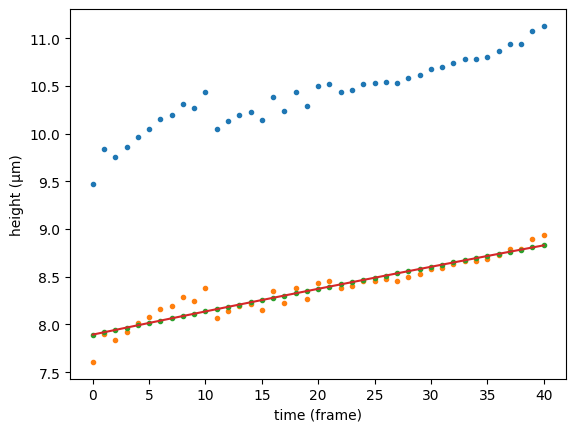

In [79]:
plt.plot(frames, h_mean, '.')
plt.plot(frames, h_mean * _3DQPI.z_to_um, '.')
plt.plot(frames, np.mean(rescaled_hstack, axis=(1,2)), '.')
plt.plot(frames, polynomial(frames,  *param) * _3DQPI.z_to_um)
plt.ylabel("height (µm)")
plt.xlabel("time (frame)")


In [80]:
# save data
for i in range(len(rescaled_hstack)):
    hframe = rescaled_hstack[i] / _3DQPI.h_to_um
    nframe = n_stack[i]

    imageio.imwrite(f"{out_path}height_fields/raw/{dataset}/MDCK-li_height_{i}.tiff",       np.array(hframe, dtype=np.uint16))
    imageio.imwrite(f"{out_path}ri_fields/raw/{dataset}/MDCK-li_refractive_index_{i}.tiff", np.array(nframe, dtype=np.uint16))